In [1]:
import os
import time
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

from skimage.metrics import (
    peak_signal_noise_ratio,
    structural_similarity,
    mean_squared_error
)

print("RLFN Joint Restoration Experiment")
print("PyTorch:", torch.__version__)

RLFN Joint Restoration Experiment
PyTorch: 2.5.1+cu121


In [2]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("Seed:", SEED)
print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Seed: 42
Device: cuda
GPU: Quadro GV100


In [3]:
GT_PATH = "../data/train/GT"
NOISY_PATH = "../data/train/NoisyLR"

files = sorted([
    f for f in os.listdir(GT_PATH)
    if f.endswith(".npy")
])

print("Total pairs:", len(files))

Total pairs: 3200


In [4]:
np.random.seed(SEED)

indices = np.random.permutation(
    len(files)
)

train_end = int(
    0.80 * len(files)
)

val_end = int(
    0.90 * len(files)
)

train_files = [
    files[i]
    for i in indices[:train_end]
]

val_files = [
    files[i]
    for i in indices[
        train_end:val_end
    ]
]

test_files = [
    files[i]
    for i in indices[
        val_end:
    ]
]

print("Train:", len(train_files))
print("Validation:", len(val_files))
print("Test:", len(test_files))

Train: 2560
Validation: 320
Test: 320


In [5]:
class KLADataset(Dataset):

    def __init__(
        self,
        gt_path,
        noisy_path,
        files
    ):

        self.gt_path = gt_path
        self.noisy_path = noisy_path
        self.files = files

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):

        filename = self.files[idx]

        lr = np.load(
            os.path.join(
                self.noisy_path,
                filename
            )
        ).astype(np.float32)

        gt = np.load(
            os.path.join(
                self.gt_path,
                filename
            )
        ).astype(np.float32)

        lr = torch.from_numpy(
            lr
        ).unsqueeze(0)

        gt = torch.from_numpy(
            gt
        ).unsqueeze(0)

        return lr, gt

In [6]:
BATCH_SIZE = 16

train_dataset = KLADataset(
    GT_PATH,
    NOISY_PATH,
    train_files
)

val_dataset = KLADataset(
    GT_PATH,
    NOISY_PATH,
    val_files
)

test_dataset = KLADataset(
    GT_PATH,
    NOISY_PATH,
    test_files
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=1,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print(
    len(train_dataset),
    len(val_dataset),
    len(test_dataset)
)

2560 320 320


In [7]:
class ESA(nn.Module):

    def __init__(
        self,
        channels
    ):

        super().__init__()

        reduced = max(
            channels // 4,
            8
        )

        self.conv1 = nn.Conv2d(
            channels,
            reduced,
            1
        )

        self.conv2 = nn.Conv2d(
            reduced,
            reduced,
            3,
            stride=2,
            padding=1
        )

        self.conv3 = nn.Conv2d(
            reduced,
            reduced,
            3,
            padding=1
        )

        self.conv4 = nn.Conv2d(
            reduced,
            channels,
            1
        )


    def forward(
        self,
        x
    ):

        c1 = self.conv1(
            x
        )

        c2 = self.conv2(
            c1
        )

        pooled = F.max_pool2d(
            c2,
            kernel_size=7,
            stride=3,
            padding=3
        )

        pooled = F.leaky_relu(
            self.conv3(
                pooled
            ),
            0.1,
            inplace=True
        )

        pooled = F.interpolate(
            pooled,
            size=x.shape[-2:],
            mode="bilinear",
            align_corners=False
        )

        mask = torch.sigmoid(
            self.conv4(
                pooled
            )
        )

        return (
            x * mask
        )

In [8]:
class RLFB(nn.Module):

    def __init__(
        self,
        channels
    ):

        super().__init__()

        self.conv1 = nn.Conv2d(
            channels,
            channels,
            3,
            padding=1
        )

        self.conv2 = nn.Conv2d(
            channels,
            channels,
            3,
            padding=1
        )

        self.conv3 = nn.Conv2d(
            channels,
            channels,
            3,
            padding=1
        )

        self.conv4 = nn.Conv2d(
            channels,
            channels,
            1
        )

        self.act = nn.LeakyReLU(
            0.1,
            inplace=True
        )

        self.esa = ESA(
            channels
        )


    def forward(
        self,
        x
    ):

        residual = x

        out = self.act(
            self.conv1(x)
        )

        out = self.act(
            self.conv2(out)
        )

        out = self.act(
            self.conv3(out)
        )

        out = self.conv4(
            out
        )

        out = (
            out
            +
            residual
        )

        out = self.esa(
            out
        )

        return out

In [9]:
class RLFNRestoration(nn.Module):

    def __init__(
        self,
        channels=48,
        num_blocks=6,
        scale=2
    ):

        super().__init__()

        self.head = nn.Conv2d(
            1,
            channels,
            3,
            padding=1
        )

        self.blocks = nn.ModuleList([
            RLFB(
                channels
            )
            for _ in range(
                num_blocks
            )
        ])

        self.body_conv = nn.Conv2d(
            channels,
            channels,
            3,
            padding=1
        )

        self.up = nn.Sequential(

            nn.Conv2d(
                channels,
                channels
                *
                scale
                *
                scale,
                3,
                padding=1
            ),

            nn.PixelShuffle(
                scale
            ),

            nn.Conv2d(
                channels,
                1,
                3,
                padding=1
            )
        )


    def forward(
        self,
        x
    ):

        features = self.head(
            x
        )

        residual = features

        for block in self.blocks:

            features = block(
                features
            )

        features = self.body_conv(
            features
        )

        features = (
            features
            +
            residual
        )

        output = self.up(
            features
        )

        return output

In [10]:
model = RLFNRestoration(
    channels=48,
    num_blocks=6,
    scale=2
).to(device)

total_params = sum(
    p.numel()
    for p in model.parameters()
)

print(
    "Parameters:",
    f"{total_params:,}"
)

Parameters: 516,025


In [11]:
dummy = torch.randn(
    2,
    1,
    128,
    128
).to(device)

model.eval()

with torch.no_grad():

    output = model(
        dummy
    )

print(
    "Input:",
    dummy.shape
)

print(
    "Output:",
    output.shape
)

assert output.shape == (
    2,
    1,
    256,
    256
)

print(
    "Shape test PASSED"
)

Input: torch.Size([2, 1, 128, 128])
Output: torch.Size([2, 1, 256, 256])
Shape test PASSED


In [12]:
def gaussian_window(
    window_size=11,
    sigma=1.5,
    channels=1,
    device="cpu"
):
    coords = torch.arange(
        window_size,
        dtype=torch.float32,
        device=device
    )

    coords = coords - window_size // 2

    g = torch.exp(
        -(coords ** 2) /
        (2 * sigma ** 2)
    )

    g = g / g.sum()

    window = (
        g[:, None] *
        g[None, :]
    )

    return window.expand(
        channels,
        1,
        window_size,
        window_size
    )

In [13]:
def differentiable_ssim(
    x,
    y,
    window_size=11
):

    channels = x.shape[1]

    window = gaussian_window(
        window_size,
        1.5,
        channels,
        x.device
    )

    mu_x = F.conv2d(
        x,
        window,
        padding=window_size // 2,
        groups=channels
    )

    mu_y = F.conv2d(
        y,
        window,
        padding=window_size // 2,
        groups=channels
    )

    mu_x2 = mu_x ** 2
    mu_y2 = mu_y ** 2
    mu_xy = mu_x * mu_y

    sigma_x = (
        F.conv2d(
            x * x,
            window,
            padding=window_size // 2,
            groups=channels
        )
        -
        mu_x2
    )

    sigma_y = (
        F.conv2d(
            y * y,
            window,
            padding=window_size // 2,
            groups=channels
        )
        -
        mu_y2
    )

    sigma_xy = (
        F.conv2d(
            x * y,
            window,
            padding=window_size // 2,
            groups=channels
        )
        -
        mu_xy
    )

    C1 = 0.01 ** 2
    C2 = 0.03 ** 2

    ssim_map = (
        (2 * mu_xy + C1)
        *
        (2 * sigma_xy + C2)
    ) / (
        (mu_x2 + mu_y2 + C1)
        *
        (sigma_x + sigma_y + C2)
        +
        1e-8
    )

    return ssim_map.mean()

In [14]:
def restoration_loss(
    output,
    target
):

    l1 = F.l1_loss(
        output,
        target
    )

    ssim_value = differentiable_ssim(
        output,
        target
    )

    ssim_loss = (
        1.0 - ssim_value
    )

    total_loss = (
        l1
        +
        0.10 * ssim_loss
    )

    return (
        total_loss,
        l1,
        ssim_loss
    )

print("Loss ready")

Loss ready


In [15]:
EPOCHS = 30

optimizer = optim.AdamW(
    model.parameters(),
    lr=2e-4,
    weight_decay=1e-4
)

scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=EPOCHS,
    eta_min=1e-6
)

print("Optimizer ready")

Optimizer ready


In [16]:
MODEL_DIR = "../models/rlfn"
RESULT_DIR = "../results/rlfn"
RESTORED_DIR = "../results/rlfn/restored"
IMAGE_DIR = "../results/rlfn/images"

for path in [
    MODEL_DIR,
    RESULT_DIR,
    RESTORED_DIR,
    IMAGE_DIR
]:
    os.makedirs(
        path,
        exist_ok=True
    )

BEST_MODEL_PATH = os.path.join(
    MODEL_DIR,
    "rlfn_best.pth"
)

print("Best model path:", BEST_MODEL_PATH)

Best model path: ../models/rlfn/rlfn_best.pth


In [17]:
def evaluate_validation(
    model,
    loader
):

    model.eval()

    psnr_values = []
    ssim_values = []

    with torch.no_grad():

        for lr, gt in loader:

            lr = lr.to(
                device,
                non_blocking=True
            )

            output = model(
                lr
            )

            output = torch.clamp(
                output,
                0,
                1
            )

            output_np = (
                output
                .cpu()
                .numpy()
            )

            gt_np = (
                gt
                .numpy()
            )

            for i in range(
                output_np.shape[0]
            ):

                pred = output_np[
                    i,
                    0
                ]

                target = gt_np[
                    i,
                    0
                ]

                psnr_values.append(
                    peak_signal_noise_ratio(
                        target,
                        pred,
                        data_range=1.0
                    )
                )

                ssim_values.append(
                    structural_similarity(
                        target,
                        pred,
                        data_range=1.0
                    )
                )

    return (
        float(np.mean(psnr_values)),
        float(np.mean(ssim_values))
    )

In [19]:
best_psnr = -1.0

train_history = []
val_psnr_history = []
val_ssim_history = []


for epoch in range(EPOCHS):

    model.train()

    running_loss = 0.0

    train_bar = tqdm(
        train_loader,
        desc=f"Epoch {epoch+1}/{EPOCHS}"
    )

    for lr, gt in train_bar:

        lr = lr.to(
            device,
            non_blocking=True
        )

        gt = gt.to(
            device,
            non_blocking=True
        )

        optimizer.zero_grad(
            set_to_none=True
        )

        output = model(
            lr
        )

        loss, _, _ = restoration_loss(
            output,
            gt
        )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            1.0
        )

        optimizer.step()

        running_loss += loss.item()

        train_bar.set_postfix(
            loss=f"{loss.item():.5f}"
        )

    train_loss = (
        running_loss /
        len(train_loader)
    )

    val_psnr, val_ssim = (
        evaluate_validation(
            model,
            val_loader
        )
    )

    scheduler.step()

    train_history.append(
        train_loss
    )

    val_psnr_history.append(
        val_psnr
    )

    val_ssim_history.append(
        val_ssim
    )

    print(
        f"Epoch [{epoch+1:02d}/{EPOCHS}] "
        f"Loss: {train_loss:.6f} | "
        f"PSNR: {val_psnr:.4f} dB | "
        f"SSIM: {val_ssim:.4f} | "
        f"LR: {optimizer.param_groups[0]['lr']:.7f}"
    )

    if val_psnr > best_psnr:

        best_psnr = val_psnr

        checkpoint = {
            "epoch":
                epoch + 1,

            "model_state_dict":
                model.state_dict(),

            "optimizer_state_dict":
                optimizer.state_dict(),

            "scheduler_state_dict":
                scheduler.state_dict(),

            "val_psnr":
                val_psnr,

            "val_ssim":
                val_ssim,

            "config": {
                "channels": 48,
                "num_blocks": 6,
                "scale": 2
            }
        }

        torch.save(
            checkpoint,
            BEST_MODEL_PATH
        )

        print("★ Best model saved")

Epoch 1/30: 100%|██████████| 160/160 [01:04<00:00,  2.47it/s, loss=0.05955]


Epoch [01/30] Loss: 0.054974 | PSNR: 27.9699 dB | SSIM: 0.7582 | LR: 0.0000015
★ Best model saved


Epoch 2/30: 100%|██████████| 160/160 [01:06<00:00,  2.42it/s, loss=0.04600]


Epoch [02/30] Loss: 0.054975 | PSNR: 27.9693 dB | SSIM: 0.7583 | LR: 0.0000032


Epoch 3/30: 100%|██████████| 160/160 [01:03<00:00,  2.51it/s, loss=0.05592]


...

Epoch [28/30] Loss: 0.054797 | PSNR: 28.0417 dB | SSIM: 0.7628 | LR: 0.0001978


Epoch 29/30: 100%|██████████| 160/160 [01:02<00:00,  2.55it/s, loss=0.04415]


Epoch [29/30] Loss: 0.054309 | PSNR: 28.0182 dB | SSIM: 0.7606 | LR: 0.0001995


Epoch 30/30: 100%|██████████| 160/160 [01:02<00:00,  2.55it/s, loss=0.06619]


Epoch [30/30] Loss: 0.054526 | PSNR: 27.9828 dB | SSIM: 0.7610 | LR: 0.0002000


In [21]:
checkpoint = torch.load(
    BEST_MODEL_PATH,
    map_location=device
)

best_model = RLFNRestoration(
    channels=
        checkpoint["config"]["channels"],

    num_blocks=
        checkpoint["config"]["num_blocks"],

    scale=
        checkpoint["config"]["scale"]
).to(device)

best_model.load_state_dict(
    checkpoint[
        "model_state_dict"
    ]
)

best_model.eval()

print(
    "Best epoch:",
    checkpoint["epoch"]
)

print(
    "Validation PSNR:",
    checkpoint["val_psnr"]
)

print(
    "Validation SSIM:",
    checkpoint["val_ssim"]
)

Best epoch: 27
Validation PSNR: 28.093130138544332
Validation SSIM: 0.7616228921323482


/tmp/ipykernel_3646488/83463895.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(


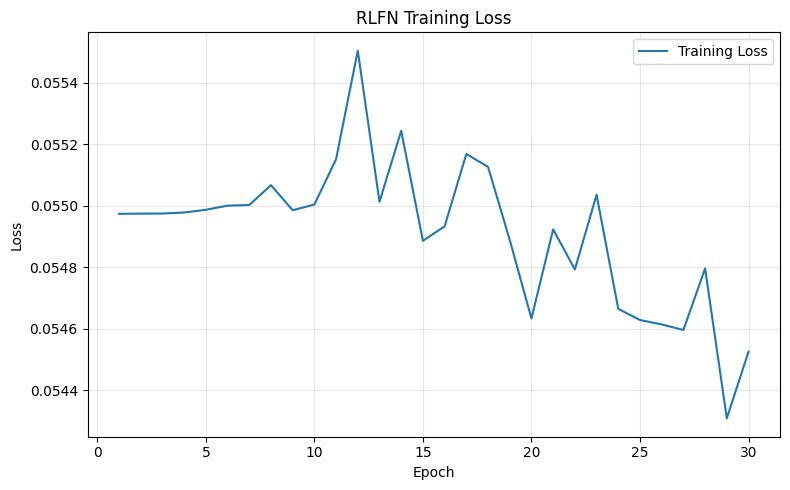

In [23]:
epochs = np.arange(
    1,
    len(train_history) + 1
)

plt.figure(
    figsize=(8,5)
)

plt.plot(
    epochs,
    train_history,
    label="Training Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("RLFN Training Loss")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig(
    os.path.join(
        IMAGE_DIR,
        "training_loss.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

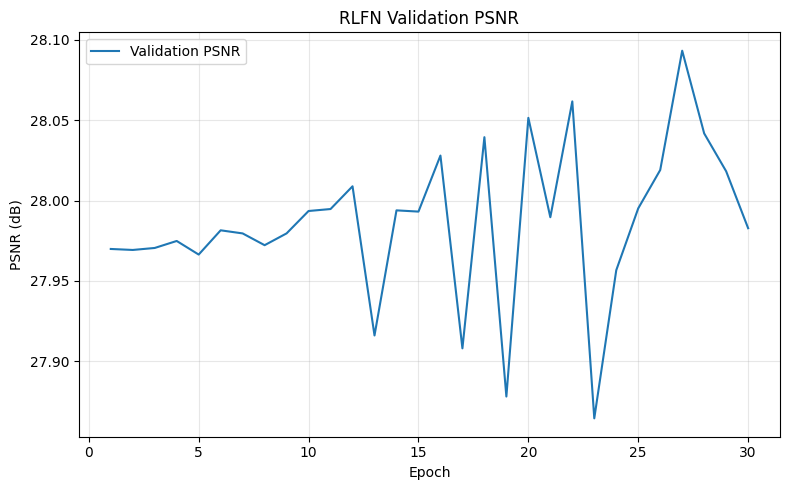

In [24]:
plt.figure(
    figsize=(8,5)
)

plt.plot(
    epochs,
    val_psnr_history,
    label="Validation PSNR"
)

plt.xlabel("Epoch")
plt.ylabel("PSNR (dB)")
plt.title("RLFN Validation PSNR")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig(
    os.path.join(
        IMAGE_DIR,
        "validation_psnr.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [25]:
psnr_scores = []
ssim_scores = []
mse_scores = []
inference_times = []

best_model.eval()

with torch.no_grad():

    for i, (lr, gt) in enumerate(
        tqdm(
            test_loader,
            desc="Testing RLFN"
        )
    ):

        lr = lr.to(
            device,
            non_blocking=True
        )

        if device.type == "cuda":
            torch.cuda.synchronize()

        start = time.perf_counter()

        output = best_model(
            lr
        )

        if device.type == "cuda":
            torch.cuda.synchronize()

        elapsed_ms = (
            time.perf_counter()
            -
            start
        ) * 1000

        output = torch.clamp(
            output,
            0,
            1
        )

        restored = (
            output
            .squeeze()
            .cpu()
            .numpy()
        )

        gt_np = (
            gt
            .squeeze()
            .numpy()
        )

        psnr_value = (
            peak_signal_noise_ratio(
                gt_np,
                restored,
                data_range=1.0
            )
        )

        ssim_value = (
            structural_similarity(
                gt_np,
                restored,
                data_range=1.0
            )
        )

        mse_value = (
            mean_squared_error(
                gt_np,
                restored
            )
        )

        psnr_scores.append(
            psnr_value
        )

        ssim_scores.append(
            ssim_value
        )

        mse_scores.append(
            mse_value
        )

        inference_times.append(
            elapsed_ms
        )

        filename = (
            test_files[i]
        )

        np.save(
            os.path.join(
                RESTORED_DIR,
                filename
            ),
            restored.astype(
                np.float32
            )
        )

print("Testing complete")

Testing RLFN: 100%|██████████| 320/320 [00:05<00:00, 62.87it/s]

Testing complete


In [26]:
metrics_df = pd.DataFrame({
    "Filename":
        test_files,

    "PSNR_dB":
        psnr_scores,

    "SSIM":
        ssim_scores,

    "MSE":
        mse_scores,

    "Inference_Time_ms":
        inference_times
})

metrics_df.to_csv(
    os.path.join(
        RESULT_DIR,
        "per_image_metrics.csv"
    ),
    index=False
)

display(
    metrics_df.head()
)

,Filename,PSNR_dB,SSIM,MSE,Inference_Time_ms
0,001218.npy,27.636908,0.793716,0.001723,26.976715
1,001158.npy,28.196991,0.545525,0.001515,7.789602
2,001415.npy,21.838101,0.754102,0.006549,6.838893
3,002896.npy,29.518080,0.823901,0.001117,7.428929
4,001527.npy,37.357148,0.933446,0.000184,7.257733


In [27]:
avg_psnr = float(
    np.mean(psnr_scores)
)

median_psnr = float(
    np.median(psnr_scores)
)

avg_ssim = float(
    np.mean(ssim_scores)
)

median_ssim = float(
    np.median(ssim_scores)
)

avg_mse = float(
    np.mean(mse_scores)
)

avg_time = float(
    np.mean(inference_times)
)

print(
    "========== RLFN FINAL RESULTS =========="
)

print(
    f"Average PSNR : "
    f"{avg_psnr:.6f} dB"
)

print(
    f"Median  PSNR : "
    f"{median_psnr:.6f} dB"
)

print(
    f"Average SSIM : "
    f"{avg_ssim:.6f}"
)

print(
    f"Median  SSIM : "
    f"{median_ssim:.6f}"
)

print(
    f"Average MSE  : "
    f"{avg_mse:.8f}"
)

print(
    f"Average inference time : "
    f"{avg_time:.3f} ms/image"
)

print(
    "Images tested:",
    len(psnr_scores)
)

========== RLFN FINAL RESULTS ==========
Average PSNR : 28.589398 dB
Median  PSNR : 28.541198 dB
Average SSIM : 0.765373
Median  SSIM : 0.801974
Average MSE  : 0.00232308
Average inference time : 6.769 ms/image
Images tested: 320


In [28]:
MODEL10_PSNR = 28.776597
MODEL10_SSIM = 0.772058
MODEL10_MSE  = 0.002261

print(
    "========== RLFN vs RESIDUAL U-NET =========="
)

print(
    f"PSNR difference : "
    f"{avg_psnr - MODEL10_PSNR:+.4f} dB"
)

print(
    f"SSIM difference : "
    f"{avg_ssim - MODEL10_SSIM:+.4f}"
)

print(
    f"MSE difference  : "
    f"{avg_mse - MODEL10_MSE:+.8f}"
)

========== RLFN vs RESIDUAL U-NET ==========
PSNR difference : -0.1872 dB
SSIM difference : -0.0067
MSE difference  : +0.00006208


In [29]:
print(
    "========== PERFORMANCE DISTRIBUTION =========="
)

print("\nPSNR")
print(
    metrics_df[
        "PSNR_dB"
    ].describe()
)

print("\nSSIM")
print(
    metrics_df[
        "SSIM"
    ].describe()
)

print("\nMSE")
print(
    metrics_df[
        "MSE"
    ].describe()
)

print(
    "\n========== FAILURE COUNTS =========="
)

print(
    "PSNR < 25:",
    (
        metrics_df[
            "PSNR_dB"
        ] < 25
    ).sum()
)

print(
    "PSNR < 27:",
    (
        metrics_df[
            "PSNR_dB"
        ] < 27
    ).sum()
)

print(
    "SSIM < 0.60:",
    (
        metrics_df[
            "SSIM"
        ] < 0.60
    ).sum()
)

print(
    "SSIM < 0.70:",
    (
        metrics_df[
            "SSIM"
        ] < 0.70
    ).sum()
)

print(
    "SSIM > 0.85:",
    (
        metrics_df[
            "SSIM"
        ] > 0.85
    ).sum()
)

========== PERFORMANCE DISTRIBUTION ==========

PSNR
count    320.000000
mean      28.589398
std        4.277064
min       10.967629
25%       25.303016
50%       28.541198
75%       31.482004
max       39.231490
Name: PSNR_dB, dtype: float64

SSIM
count    320.000000
mean       0.765373
std        0.149346
min        0.258803
25%        0.705325
50%        0.801974
75%        0.874318
max        0.966664
Name: SSIM, dtype: float64

MSE
count    320.000000
mean       0.002323
std        0.004801
min        0.000119
25%        0.000711
50%        0.001399
75%        0.002949
max        0.080027
Name: MSE, dtype: float64

========== FAILURE COUNTS ==========
PSNR < 25: 70
PSNR < 27: 125
SSIM < 0.60: 40
SSIM < 0.70: 79
SSIM > 0.85: 102


In [30]:
comparison_df = pd.DataFrame({

    "Method": [
        "Bicubic",
        "SRCNN",
        "DnCNN",
        "EDSR",
        "NAF-SR",
        "Residual U-Net SR",
        "DA Residual U-Net V2",
        "RLFN"
    ],

    "PSNR_dB": [
        22.478416,
        27.529432,
        27.893001,
        27.986647,
        27.840080,
        28.776597,
        28.771419,
        avg_psnr
    ],

    "SSIM": [
        0.511662,
        0.725071,
        0.724960,
        0.742506,
        0.743259,
        0.772058,
        0.772428,
        avg_ssim
    ],

    "MSE": [
        0.007338,
        0.002734,
        0.002575,
        0.002600,
        0.002665,
        0.002261,
        0.002266,
        avg_mse
    ]
})

comparison_df.to_csv(
    os.path.join(
        RESULT_DIR,
        "baseline_comparison.csv"
    ),
    index=False
)

display(
    comparison_df
)

,Method,PSNR_dB,SSIM,MSE
0,Bicubic,22.478416,0.511662,0.007338
1,SRCNN,27.529432,0.725071,0.002734
2,DnCNN,27.893001,0.724960,0.002575
3,EDSR,27.986647,0.742506,0.002600
4,NAF-SR,27.840080,0.743259,0.002665
5,Residual U-Net SR,28.776597,0.772058,0.002261
6,DA Residual U-Net V2,28.771419,0.772428,0.002266
7,RLFN,28.589398,0.765373,0.002323
